## Step 17 — Demand forecasting model

Our goal now:

Predict daily sales at the store-family-date level

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
model_df = pd.read_csv("data/processed/modeling_data_features.csv")
model_df["date"] = pd.to_datetime(model_df["date"])

## Modelling Columns

In [5]:
forecast_df = model_df.dropna(subset=[
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
    "rolling_std_7", "rolling_std_28"
]).copy()

In [6]:
forecast_df.shape

(2950992, 37)

## Features and Target

In [7]:
feature_cols = [
    "store_nbr",
    "onpromotion",
    "transactions",
    "dcoilwtico",
    "is_holiday",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "quarter",
    "has_promotion",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28"
]

target_col = "sales"

In [8]:
X = forecast_df[feature_cols]
y = forecast_df[target_col]

## Time-based train/test split

In [9]:
split_date = "2017-01-01"

train_df = forecast_df[forecast_df["date"] < split_date].copy()
test_df = forecast_df[forecast_df["date"] >= split_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2546478, 21)
Test shape: (404514, 21)


## building  a naive baseline

In [10]:
baseline_pred = X_test["lag_1"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R2:", baseline_r2)

Baseline MAE: 135.7675549657752
Baseline RMSE: 528.2512772006586
Baseline R2: 0.8480569046574296


## Linear Regression model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression MAE: 97.6701924236595
Linear Regression RMSE: 342.7161497811487
Linear Regression R2: 0.9360458106775271


## Random Forest model

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 72.68523796432434
Random Forest RMSE: 279.04633638293046
Random Forest R2: 0.9576013031989559


## Comparison of Results in one table

In [13]:
results = pd.DataFrame({
    "Model": ["Baseline (lag_1)", "Linear Regression", "Random Forest"],
    "MAE": [baseline_mae, lr_mae, rf_mae],
    "RMSE": [baseline_rmse, lr_rmse, rf_rmse],
    "R2": [baseline_r2, lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Baseline (lag_1),135.767555,528.251277,0.848057
1,Linear Regression,97.670192,342.716150,0.936046
2,Random Forest,72.685238,279.046336,0.957601


## Visualization of Actual vs Predicted 

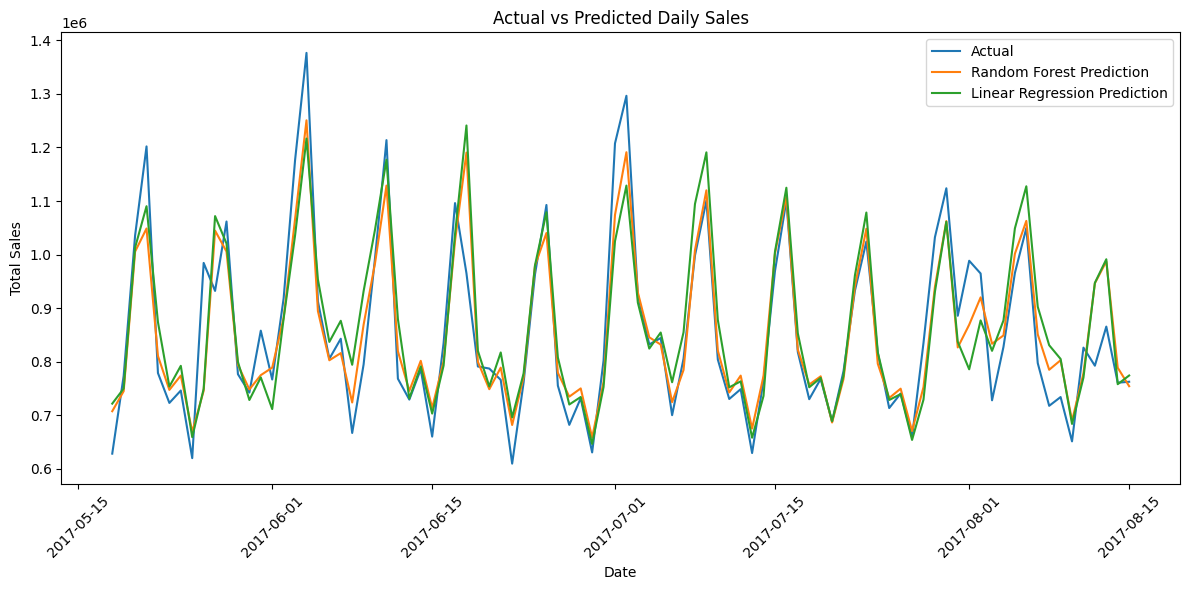

In [14]:
comparison_df = test_df[["date", "sales"]].copy()
comparison_df["rf_pred"] = rf_pred
comparison_df["lr_pred"] = lr_pred
comparison_df["baseline_pred"] = baseline_pred.values

daily_compare = comparison_df.groupby("date", as_index=False).agg({
    "sales": "sum",
    "rf_pred": "sum",
    "lr_pred": "sum",
    "baseline_pred": "sum"
})

plot_df = daily_compare.tail(90).copy()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(plot_df["date"], plot_df["sales"], label="Actual")
plt.plot(plot_df["date"], plot_df["rf_pred"], label="Random Forest Prediction")
plt.plot(plot_df["date"], plot_df["lr_pred"], label="Linear Regression Prediction")
plt.xticks(rotation=45)
plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

## Features Importance from Random Forest along with the Plot

In [15]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
16,rolling_mean_7,0.727116
14,lag_7,0.157456
15,lag_14,0.057287
13,lag_1,0.020696
2,transactions,0.014103
19,rolling_std_7,0.007381
7,day,0.003293
8,day_of_week,0.002025
1,onpromotion,0.001894
20,rolling_std_28,0.001819


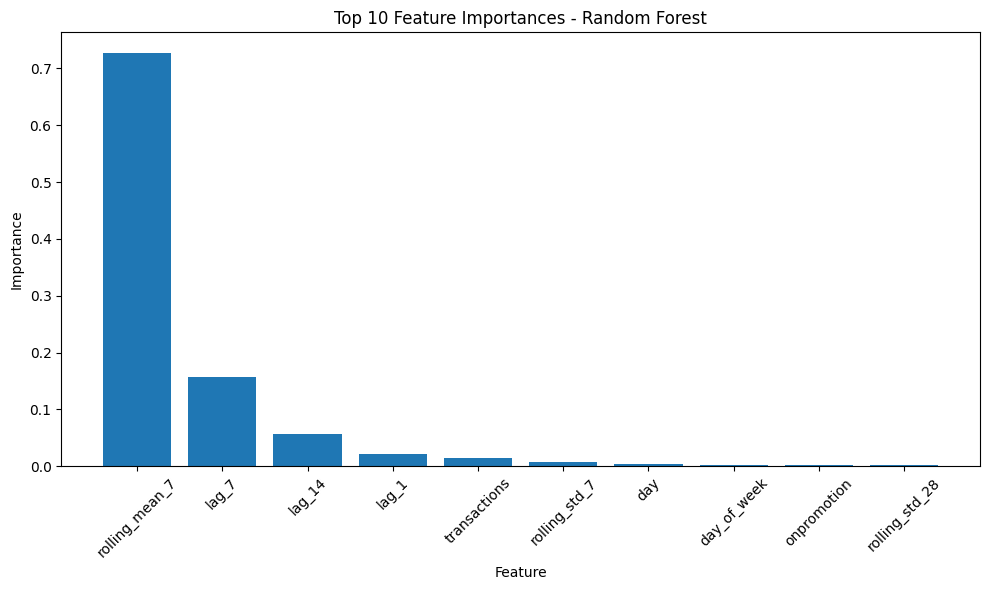

In [16]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_features["feature"], top_features["importance"])
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## cliping negative predictions

In [17]:
lr_pred_clipped = np.maximum(lr_pred, 0)
rf_pred_clipped = np.maximum(rf_pred, 0)

In [18]:
print("Linear Regression MAE (clipped):", mean_absolute_error(y_test, lr_pred_clipped))
print("Random Forest MAE (clipped):", mean_absolute_error(y_test, rf_pred_clipped))

Linear Regression MAE (clipped): 90.16220378309987
Random Forest MAE (clipped): 72.68523796432434


## Step 17 — Forecasting model findings
- A time-based split was used instead of random splitting to preserve the temporal structure of the retail data.
- A naive baseline using previous-day sales was evaluated first.
- Linear Regression provided a simple benchmark model.
- Random Forest captured non-linear relationships and was expected to perform better than the linear model.
- Lag and rolling-demand features were among the most important predictors, confirming the importance of recent sales history in retail forecasting.